# Which listed members does Marketing call first, and does each flag hold up when a member says they were on holiday?

**Week 2, Wednesday. Chapter 6 of 6.** The protect list and the flag meet: Marketing calls
the flagged members on the list first, and one member has already pushed back.

> "Before we ring anyone: one of your flagged members, C-0216, rang our help line to say they
> were travelling in August and have not stopped buying. Is your flag wrong about them, and
> how many others?"
> The head of Retail-Plus, Kalpa Retail

**Who needs the answer.** The marketing lead's member team rings the flagged members on the
protect list this week, and the head of Retail-Plus answers to the tier's members for every
call. A call that tells a loyal member their spend is falling when they were away costs their
goodwill and maybe their renewal, and a call list padded with false alarms spends the team's
week on members who were never drifting.

**The questions on the way.**
1. Which ways could the flag read "last month", and what would each cost?
2. How many of the flagged members are on the protect list?
3. What did LAG compare for the member who says they were on holiday?
4. How many of the sixteen flags step over a month with no order?
5. Does a join on calendar months find the same members?
6. Who does Marketing call first?

**The metric at stake.** Monthly spend, a member's booked revenue in one calendar month, and
the flag: spend in September below August, and August below July. A month with no order has
no row in the monthly table. The retail dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, section 8, prices a wrong
retention flag: offers spent on the wrong members while the ones at risk lapse.

**What chapters 1 to 5 found.** Each segment's protect list is its top fifty by Q2 revenue
under RANK, the head of Retail-Plus's rule, so members who spent the same share a place.
Chapter 4's flag, LAG over each member's months with PARTITION BY customer_id, found 16
members whose September was below their month before, and that month below the one before
it. Q2 itself closed on plan, Rs 9,84,00,000 against Rs 9,83,99,990.

**A real company with the same question.** Shopify's data team warned merchants that "far
too often businesses define churn as no purchases after N days", and read a customer's gap
against that customer's own history: one who bought almost daily and has not been seen in
months is unlikely to still be active (Cam Davidson-Pilon, "How Shopify Merchants can
Measure Retention", Shopify Engineering, 14 November 2017, checked 1 October 2026). Hotel
programmes treated a gap the member did not choose as no reading: Marriott extended elite
status earned in 2019 until February 2022, and Hilton extended status to 31 March 2022 for
members set to downgrade in 2020 or 2021 (Marriott's release of 14 April 2020 and Hilton's
of 27 October 2020, checked 1 October 2026).

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_06_call_first_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("06_call_first")
print(len(Q), "named queries read from", "C2_W02_D03_06_call_first_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

10 named queries read from C2_W02_D03_06_call_first_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


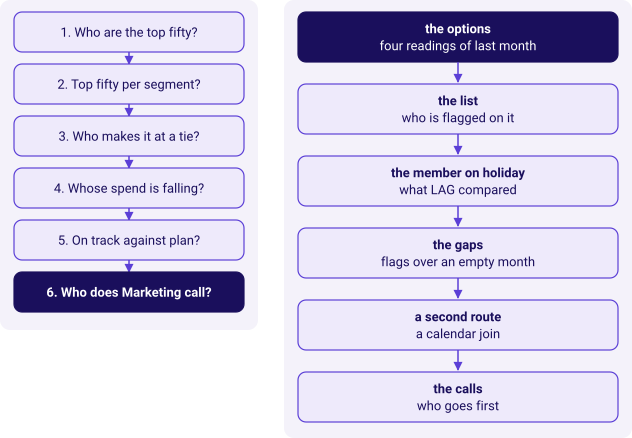

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=5, show=False),
    kit.vflow(['the options\nfour readings of last month', 'the list\nwho is flagged on it', 'the member on holiday\nwhat LAG compared', 'the gaps\nflags over an empty month', 'a second route\na calendar join', 'the calls\nwho goes first'], lit=0, show=False),
)

## The options: which ways could the flag read "last month", and what would each cost?

Marketing's words are "monthly spend has fallen for two months running", which reads as
calendar months: September below August, August below July.

| Option | What "last month" is | Rows it reads | What a month with no order does |
|---|---|---|---|
| A. LAG over the member's own months, chapter 4's flag | the last month before this one in which the member bought | every member-month | is stepped over, so the months either side are compared |
| B. LAG with a check that the two rows before September are August and July | the calendar month before | every member-month | breaks the run, so no flag |
| C. A calendar of every member and every month, with zero where there is no order | the calendar month before | every member times six months | reads as spend of zero, so a quiet month becomes a fall |
| D. The same calendar, left empty where there is no order | the calendar month before | every member times six months | stays empty, so no flag |

**Predict before you run.** In how many of the six months does a member who bought place an
order, on average?

- a) About 2.5.
- b) All six.
- c) About 5.
- d) About 1.

option,rows read
A. LAG over own months,752
B. LAG with a calendar check,752
"C. calendar, zero-filled","1,806"
"D. calendar, left empty","1,806"


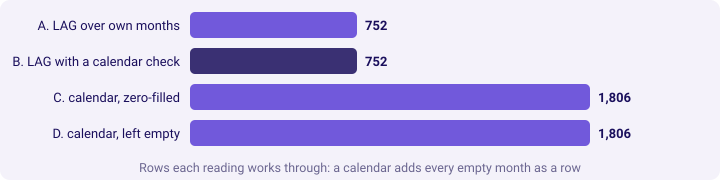

In [3]:
per = rows(Q["c6_months_per_member"])[0]
cal = rows(Q["c6_calendar_table"])[0]
sizing = [("A. LAG over own months", per["member_months"]), ("B. LAG with a calendar check", per["member_months"]),
          ("C. calendar, zero-filled", cal["calendar_rows"]), ("D. calendar, left empty", cal["calendar_rows"])]
kit.table(["option", "rows read"], [(o, f"{n:,}") for o, n in sizing],
          caption=f"{per['members']} members, {per['months_with_an_order_each']} months with an order each, on average")
kit.bars(sizing, title="Rows each reading works through: a calendar adds every empty month as a row", lit=(1,))

**What happened.** The answer is a: 752 member-months for 301 members, 2.5 months with an
order each out of six. A month with no order is the usual state for a Kalpa member, so a
zero-filled calendar, option C, reads a quiet month as a fall to zero: it flags 26 members, 17
of whom simply placed no order in September. Options B and D read calendar months; B works
through the 752 rows that exist and D through 1,806, every member in every month.

**The best-fit call.** Option B: LAG with a check that the two rows before September are
August and July. It reads only the rows that exist and adds two columns. **What would change
the call:** if Marketing also wants "went quiet" as a signal of its own, a member who bought
in July and August and nothing in September, the calendar of option D makes those empty months
rows a query can count.

In [4]:
kit.check("2.5 months with an order per member", float(per["months_with_an_order_each"]) == 2.5)
kit.check("the calendar holds 1,806 rows, 301 members times six months", cal["calendar_rows"] == 1806 == 301 * 6)
kit.check("a zero-filled calendar flags 26, of whom 17 placed no September order",
          (cal["flagged_zero_months"], cal["zero_flags_with_no_september_order"]) == (26, 17))

## 1. How many of the flagged members are on the protect list?

The protect list is each segment's top fifty under RANK; the flag is chapter 4's partitioned
LAG. Marketing calls the members who are on both.

**Predict before you run.** How many of chapter 4's 16 flagged members are on a protect list?

- a) All 16.
- b) About half.
- c) None, since the list is about spend and the flag about falls.
- d) It cannot be known without the tie rule.

In [5]:
both = rows(Q["c6_on_the_list"])[0]
kit.stats([(both["members_flagged"], "members flagged", "chapter 4's partitioned LAG"),
           (both["flagged_on_the_list"], "on a protect list", "each segment's top fifty under RANK")],
          caption="Who Marketing would ring, before the head of Retail-Plus's message")
kit.check("every flagged member is on a protect list", both["flagged_on_the_list"] == both["members_flagged"] == 16)

**What happened.** The answer is a: all 16 flagged members are on a protect list, since a
member whose spend can fall twice from a high month is a member who spent a lot. Marketing's
call sheet would read 16 names.

## 2. What did LAG compare for the member who says they were on holiday?

C-0216 of Retail-Plus stands at place 23 on the Retail-Plus list. Carry the month LAG read
beside the spend it read.

**Predict before you run.** Which month did LAG treat as "last month" for C-0216's September?

- a) August.
- b) July.
- c) June.
- d) None, since their August is empty.

customer_id,month,spend,month_1_back,spend_1_back,month_2_back,spend_2_back
C-0216,2026-05-01,"Rs 6,440",NULL,NULL,NULL,NULL
C-0216,2026-07-01,"Rs 4,300",2026-05-01,"Rs 6,440",NULL,NULL
C-0216,2026-09-01,"Rs 2,540",2026-07-01,"Rs 4,300",2026-05-01,"Rs 6,440"


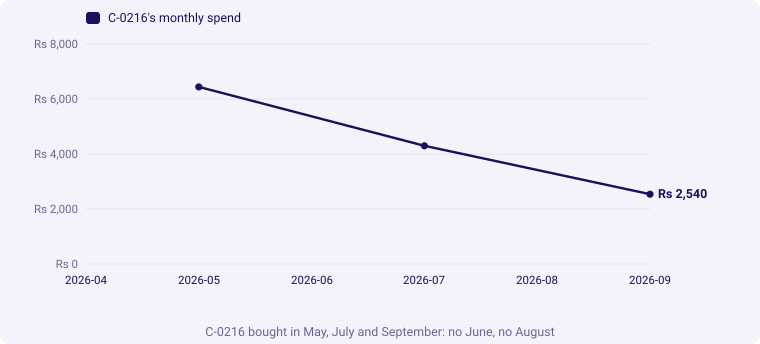

In [6]:
his = run("c6_holiday_member", "C-0216: each month with the months LAG read",
          money=("spend", "spend_1_back", "spend_2_back"), echo=False)
labels = ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"]
spent = {str(r["month"])[:7]: r["spend"] for r in his}
kit.line(labels, [("C-0216's monthly spend", [spent.get(m) for m in labels], "lit")],
         title="C-0216 bought in May, July and September: no June, no August", fmt=kit.rupees)

**What happened.** The answer is b. C-0216 bought in May (Rs 6,440), July (Rs 4,300) and
September (Rs 2,540). LAG reads the previous row, and with no order in August there is no
August row, so it compared September with July and July with May, four months apart. Chapter
4's flag called that two months of falls; C-0216 says August was a holiday, and the member's
own rows agree that August is simply empty.

In [7]:
sep = his[-1]
kit.check("LAG read July as last month for September", str(sep["month_1_back"]) == "2026-07-01")
kit.check("and May as the month before that", str(sep["month_2_back"]) == "2026-05-01")
kit.check("C-0216 has no August row", "2026-08" not in spent)

## 3. How many of the sixteen flags step over a month with no order?

**The plausible wrong answer.** Ship chapter 4's flag as it stands: sixteen calls, each member
told that their spend has fallen two months running. Answered for C-0216, the hurried reply is
that the member did spend less with each order.

**Why it is wrong.** Marketing asked about calendar months, and LAG counts rows. Wherever a
member skipped a month, LAG steps over the gap and compares months that are further apart, so
a holiday reads as a fall and the call accuses a loyal member.

**The check that exposes it.** Count the flags whose two rows before September are not August
and July.

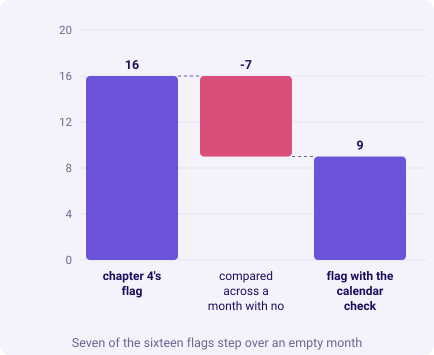

In [8]:
gaps = rows(Q["c6_gap_check"])[0]
kept = rows(Q["c6_calendar_flag"])[0]["members_flagged"]
kit.bridge(("chapter 4's flag", gaps["members_flagged"]),
           [("compared across a month with no order", -gaps["across_a_month_with_no_order"])],
           end_label="flag with the calendar check", title="Seven of the sixteen flags step over an empty month",
           fmt=lambda v: f"{v:,.0f}")
kit.check("seven flags step over a month with no order", gaps["across_a_month_with_no_order"] == 7)
kit.check("the calendar check keeps nine", kept == 9 == gaps["members_flagged"] - gaps["across_a_month_with_no_order"])

**What happened.** Seven of the sixteen flags compare September with a month before the one
before it, because the member placed no order in July or August. C-0216 is one of the seven.

**The fix, and what it changed.** Option B: the flag holds only when the two rows before
September are August and July.

```sql
AND month_1_back = DATE '2026-08-01'
AND month_2_back = DATE '2026-07-01'
```

Nine members keep the flag. Seven calls are not made, C-0216's among them, and every call that
goes out describes three consecutive months that each fell.

## A second route: does a join on calendar months find the same members?

A self-join needs no window: it joins each member's September row to the same member's August
row and July row by date and keeps the members whose spend fell at each step. A missing month
has no row to join to, so a gap breaks the run here too, by construction.

**Predict before you run.** How many members does the calendar join keep?

- a) 9, the same members.
- b) 16.
- c) 7.
- d) 26.

In [9]:
joined = {r["customer_id"] for r in rows(Q["c6_second_route"])}
checked = {r["customer_id"] for r in rows(Q["c6_calendar_ids"])}
kit.table(["route", "members flagged"], [("LAG with the calendar check", len(checked)),
                                        ("join on calendar months", len(joined))],
          caption="Two routes, one flag")
kit.check("the join keeps the same members as the checked LAG", joined == checked, f"{len(joined)} members")

route,members flagged
LAG with the calendar check,9
join on calendar months,9


**What happened.** The answer is a: the join keeps the same nine members as the checked LAG,
member for member. The two share no window and agree because both read calendar months.

## 4. Who does Marketing call first?

All nine flagged members are on a protect list, since the list is wider than the flag. One of
them shows what a fall that holds up looks like: C-0010 of Retail-Core, first on the
Retail-Core list.

customer_id,month,spend
C-0010,2026-07-01,"Rs 7,840"
C-0010,2026-08-01,"Rs 4,080"
C-0010,2026-09-01,"Rs 1,990"


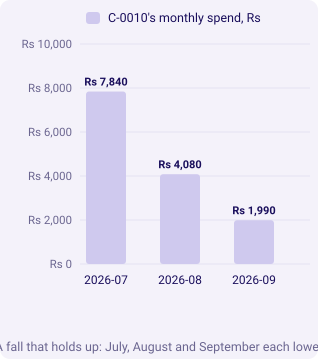

In [10]:
his = run("c6_genuine_fall", "C-0010, the top of Retail-Core's list, in each Q2 month", money=("spend",), echo=False)
kit.columns([str(r["month"])[:7] for r in his], [("C-0010's monthly spend, Rs", [r["spend"] for r in his])],
            title="A fall that holds up: July, August and September each lower", fmt=kit.rupees)
calls = rows(Q["c6_call_list"])
kit.check("nine members to call, all on a protect list", len(calls) == 9)
kit.check("every call describes three consecutive months, each lower",
          all(r["september"] < r["august"] < r["july"] for r in calls))

**Your turn.** Type these lines into the empty cell below and run it. The block is
`c6_call_list` of the chapter's `.sql` file: the nine members with their segment, their place
on the list and their three months.

```python
calls = run("c6_call_list", "Marketing's first calls", money=("july", "august", "september"))
```

Read the nine before you write the line to Marketing: which segments they come from, how high
on each list they stand, and how far each one's spend fell.

**What happened.** C-0010 spent Rs 7,840 in July, Rs 4,080 in August and Rs 1,990 in
September, three consecutive months, each lower. Marketing's first calls are the nine members
the checked flag keeps, every one of them on a protect list; the member on holiday is not
among them, and the call script describes months the member can check on their own statement.

> **Kavya's review.** A month with no order is no reading. Write that into the flag's
> definition, and read the rows behind a flag before a call goes out.

### In the interview: how does your flag treat a month with no orders?

**[D] A member says they were on holiday in August and should not be flagged. How does your
definition treat a month with no orders, and why not fill it with zero?** A month with no
order is no reading, so it breaks the run and the member is not flagged; the check is that
the rows LAG reads are the calendar months before. Filling the empty month with zero would
read a quiet month as a fall to zero, and Kalpa's members buy in about 2.5 of six months, so
zeros would flag 26 members here, 17 of them only for a quiet September.

**[D] Marketing also wants members who went quiet. How would you build that flag?** Build it
on a calendar of every member and every month, left empty where there is no order, so a quiet
month becomes a row the query can see: bought in July and August, nothing in September. It
is a second flag with its own name, never mixed into the falling-spend flag.

### Depth: what would a zero-filled calendar have flagged?

Option C turns every quiet September into a fall to zero. The counts below come from the same
calendar, read both ways.

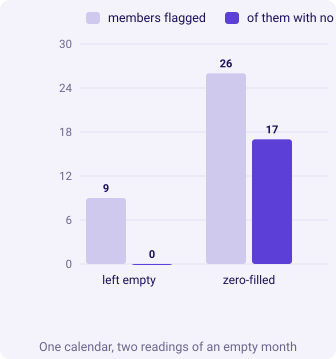

In [11]:
kit.columns(["left empty", "zero-filled"],
            [("members flagged", [cal["flagged_empty_months"], cal["flagged_zero_months"]]),
             ("of them with no September order", [0, cal["zero_flags_with_no_september_order"]])],
            title="One calendar, two readings of an empty month")
kit.check("the calendar left empty agrees with the checked LAG", cal["flagged_empty_months"] == 9)

Left empty, the calendar flags the same nine. Zero-filled, it flags 26, and 17 of them had no
September order at all, which is a different question, who went quiet, answered by accident.

## What did this chapter answer?

1. **Which reading of "last month"?** The calendar month before, checked on LAG's own rows:
   752 rows, where a calendar reads 1,806 and a zero-filled one flags 26.
2. **How many flagged members are on the list?** All 16 of chapter 4's flag.
3. **What did LAG compare for C-0216?** September with July and July with May, stepping over
   an empty June and August.
4. **How many flags step over an empty month?** 7 of 16; the calendar check keeps 9.
5. **Does a calendar join agree?** Yes, the same nine members.
6. **Who does Marketing call first?** The nine checked flags, all on a protect list, C-0010 of
   Retail-Core among them and the member on holiday not.

**The day's answer, to Marketing and the head of Retail-Plus.** Each segment's protect list is
its top fifty by Q2 revenue under RANK, so members who spent the same share a place: Business
and Student list every Q2 buyer, 35 and 20, Retail-Core lists 50, and Retail-Plus lists the
count your own run gave, with the reason in the same line if it is not fifty. Call the nine
members whose spend fell in August and again in September first; a month with no order is no
reading, so the member on holiday is not one of them. Q2 closed on plan, Rs 9,84,00,000 against
Rs 9,83,99,990, and the Rs 1.58 crore lead at mid-quarter came from one week in July, so the
weekly run rate has sat below plan since 10 August.

In [12]:
kit.check_summary()